<a href="https://colab.research.google.com/github/dougyd92/ML-Foudations/blob/main/Notebooks/16_CNN_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Session 16: CNNs in Practice & Transfer Learning

*Machine Learning Foundations — Codecademy Live Learning*

**Part 1 of today's session:** hands-on CNN coding patterns you'll need for Project 4.

In this notebook we will:
- Set up **Datasets and DataLoaders** — PyTorch's data pipeline
- Build a CNN using `nn.Module` — understanding every line
- Walk through the **training loop** with validation, `model.train()` vs `model.eval()`
- Build the **same CNN in Keras** — side-by-side comparison
- Inspect, debug, and evaluate CNN models
- Practice the complete workflow you'll use for Project 4

We'll use **Fashion-MNIST** throughout: 28×28 grayscale images of 10 clothing categories.

## Setup

In [1]:
# Setup: Run this cell first
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers as klayers
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)
tf.random.set_seed(42)

# Matplotlib defaults
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Device setup for PyTorch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"TensorFlow version: {tf.__version__}")
print("All imports successful!")

PyTorch device: cuda
PyTorch version: 2.10.0+cu128
TensorFlow version: 2.19.0
All imports successful!


---
# Loading and Preparing the Data

Before we build any models, we need to get the data into the right format. This is where many beginners get tripped up — PyTorch and Keras expect different tensor shapes, and PyTorch requires you to set up a data pipeline explicitly.

In [2]:
# Load Fashion-MNIST via Keras (convenient loader)
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = keras.datasets.fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Training set: {X_train_raw.shape}, Labels: {y_train_raw.shape}")
print(f"Test set:     {X_test_raw.shape}, Labels: {y_test_raw.shape}")
print(f"Pixel range:  {X_train_raw.min()} to {X_train_raw.max()}")
print(f"Classes ({len(class_names)}): {class_names}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training set: (60000, 28, 28), Labels: (60000,)
Test set:     (10000, 28, 28), Labels: (10000,)
Pixel range:  0 to 255
Classes (10): ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


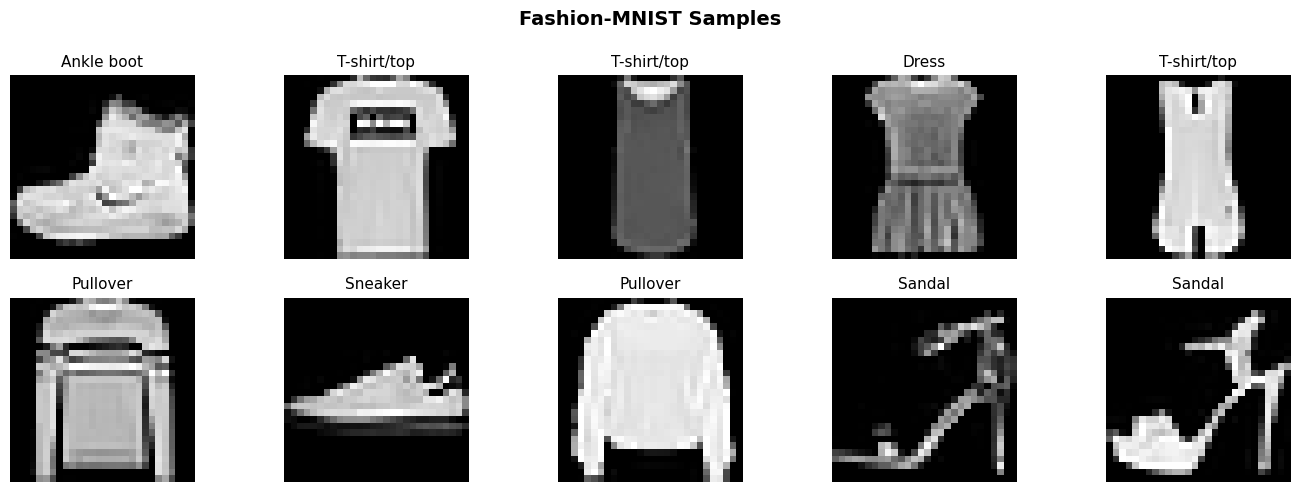

In [3]:
# Visualize a few samples
fig, axes = plt.subplots(2, 5, figsize=(14, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train_raw[i], cmap='gray')
    ax.set_title(class_names[y_train_raw[i]], fontsize=11)
    ax.axis('off')
plt.suptitle('Fashion-MNIST Samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Normalization

Neural networks train better when inputs are in [0, 1] rather than [0, 255]. We divide by 255 — same idea as `StandardScaler` from classical ML, just simpler for image pixels.

In [4]:
# Normalize to [0, 1]
X_train_np = X_train_raw.astype('float32') / 255.0
X_test_np = X_test_raw.astype('float32') / 255.0
print(f"After normalization: min={X_train_np.min():.1f}, max={X_train_np.max():.1f}")

After normalization: min=0.0, max=1.0


---
# Section 1: PyTorch Data Pipeline — Datasets and DataLoaders

In sklearn, you pass `X_train` and `y_train` directly to `.fit()`. PyTorch adds an extra layer: you wrap your data in a **Dataset**, then feed it through a **DataLoader** that handles batching and shuffling.

This might feel like unnecessary overhead for Fashion-MNIST, but it's the same pattern used for massive datasets that don't fit in memory. Learning it now pays off immediately in Project 4.

### Step 1: Reshape for PyTorch

PyTorch CNNs expect tensors shaped `(batch, channels, height, width)` — channels first. A grayscale image is 1 channel. Compare to Keras, which expects `(batch, height, width, channels)` — channels last.

In [6]:
# PyTorch: (N, C, H, W) — channels FIRST
X_train_pt = torch.FloatTensor(X_train_np).unsqueeze(1)  # adds channel dim at position 1
y_train_pt = torch.LongTensor(y_train_raw.copy())
X_test_pt = torch.FloatTensor(X_test_np).unsqueeze(1)
y_test_pt = torch.LongTensor(y_test_raw.copy())

print(f"Original numpy shape: {X_train_np.shape}")
print(f"PyTorch tensor shape: {X_train_pt.shape}  ← (N, C, H, W)")
print(f"One image shape:      {X_train_pt[0].shape}  ← (channels, height, width)")

Original numpy shape: (60000, 28, 28)
PyTorch tensor shape: torch.Size([60000, 1, 28, 28])  ← (N, C, H, W)
One image shape:      torch.Size([1, 28, 28])  ← (channels, height, width)


### Step 2: Create a TensorDataset

A `TensorDataset` bundles features and labels together. When you index into it, you get a `(feature, label)` pair — like a list of tuples.

In [10]:
# TensorDataset: pairs features with labels
full_train_dataset = TensorDataset(X_train_pt, y_train_pt)
test_dataset = TensorDataset(X_test_pt, y_test_pt)

# Indexing returns a (feature_tensor, label_tensor) pair
sample_x, sample_y = full_train_dataset[0]
print(f"Dataset length: {len(full_train_dataset)}")
print(f"One sample: feature shape={sample_x.shape}, label={sample_y.item()} ({class_names[sample_y]})")

Dataset length: 60000
One sample: feature shape=torch.Size([1, 28, 28]), label=9 (Ankle boot)


### Step 3: Split Training into Train + Validation

We need a validation set to monitor overfitting during training. `random_split` splits a Dataset into non-overlapping subsets.

In [11]:
# Split: 50,000 train, 10,000 validation
train_dataset, val_dataset = random_split(
    full_train_dataset, [50000, 10000],
    generator=torch.Generator().manual_seed(42)  # reproducible split
)
print(f"Training samples:   {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples:       {len(test_dataset)}")

Training samples:   50000
Validation samples: 10000
Test samples:       10000


### Step 4: Create DataLoaders

The **DataLoader** is where the magic happens. It:
- **Batches** your data (you set `batch_size`)
- **Shuffles** training data each epoch (set `shuffle=True` for training only)
- Handles the iteration — you loop over batches, not individual samples

This is what replaces sklearn's implicit batching inside `.fit()`.

In [12]:
# DataLoaders: batch, shuffle, iterate
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

# Let's see what one batch looks like
X_batch, y_batch = next(iter(train_loader))
print(f"One training batch:")
print(f"  Features shape: {X_batch.shape}  ← (batch_size, channels, H, W)")
print(f"  Labels shape:   {y_batch.shape}")
print(f"  Labels sample:  {y_batch[:8].tolist()}")
print(f"\nBatches per epoch: {len(train_loader)}  (50000 / 64 ≈ 782)")

One training batch:
  Features shape: torch.Size([64, 1, 28, 28])  ← (batch_size, channels, H, W)
  Labels shape:   torch.Size([64])
  Labels sample:  [0, 1, 1, 4, 2, 0, 4, 6]

Batches per epoch: 782  (50000 / 64 ≈ 782)


### Why shuffle training but not validation?

Shuffling training data ensures the model sees samples in a different order each epoch — this prevents it from memorizing sequence patterns and provides better gradient estimates. Validation data doesn't need shuffling because we're just computing metrics, not learning from it.

**Quick reference — the DataLoader pattern:**
```python
# Training: shuffle=True, moderate batch size
train_loader = DataLoader(dataset, batch_size=64, shuffle=True)

# Validation/Test: shuffle=False, larger batch size (faster, no gradient needed)
val_loader = DataLoader(dataset, batch_size=256, shuffle=False)
```

---
# Section 2: Building a CNN in PyTorch

You saw the CNN architecture pattern in Session 15: Conv → BatchNorm → ReLU → Pool, repeated, then Flatten → Dense → Output. Now let's build one line by line, understanding what each piece does and why.

### Defining the Model: `nn.Module`

Every PyTorch model is a class that inherits from `nn.Module`. It has two required pieces:
1. **`__init__`**: define all your layers (the learnable parts)
2. **`forward`**: wire them together (the computation path)

This is where you make architecture decisions: how many conv layers, how many filters, where to put dropout, etc.

In [15]:
class FashionCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # --- Conv Block 1: 1 input channel → 32 filters ---
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)       # normalize 32 channels

        # --- Conv Block 2: 32 → 64 filters ---
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # --- Shared layers ---
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # halves spatial dimensions
        self.dropout_conv = nn.Dropout2d(0.25)              # spatial dropout for conv layers
        self.dropout_fc = nn.Dropout(0.5)                   # regular dropout for dense layers

        # --- Classifier head ---
        # After 2 pool layers: 28 → 14 → 7, with 64 channels: 64 * 7 * 7 = 3136
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # Block 1: Conv → BN → ReLU → Pool → Dropout
        x = self.conv1(x)          # (B, 1, 28, 28) → (B, 32, 28, 28)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool(x)           # (B, 32, 28, 28) → (B, 32, 14, 14)
        x = self.dropout_conv(x)

        # Block 2: Conv → BN → ReLU → Pool → Dropout
        x = self.conv2(x)          # (B, 32, 14, 14) → (B, 64, 14, 14)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool(x)           # (B, 64, 14, 14) → (B, 64, 7, 7)
        x = self.dropout_conv(x)

        # Flatten and classify
        x = x.view(x.size(0), -1)  # (B, 64, 7, 7) → (B, 3136)
        x = F.relu(self.fc1(x))    # (B, 3136) → (B, 128)
        x = self.dropout_fc(x)
        x = self.fc2(x)            # (B, 128) → (B, 10)
        return x                    # raw logits (CrossEntropyLoss applies softmax)

model = FashionCNN().to(device)
print(model)

FashionCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout_conv): Dropout2d(p=0.25, inplace=False)
  (dropout_fc): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


### Understanding the Architecture

A few things to notice in the code above:

**`padding=1` with `kernel_size=3`**: This is "same" padding — the output has the same spatial dimensions as the input. Without it, each conv layer would shrink the feature map by 2 pixels (one on each side).

**`x.view(x.size(0), -1)`**: This is the flatten operation. `x.size(0)` keeps the batch dimension; `-1` tells PyTorch to figure out the rest. It's equivalent to `nn.Flatten()` but written explicitly.

**Raw logits, not softmax**: The `forward` method returns raw scores. `nn.CrossEntropyLoss` combines softmax + log + NLL loss internally, so applying softmax yourself would double-apply it.

**Dropout2d vs Dropout**: `Dropout2d` drops entire feature map channels (good for conv layers); `Dropout` drops individual neurons (good for dense layers).

### Counting Parameters

Before training, always check: how many parameters does this model have? This tells you how much capacity the network has — and how likely it is to overfit.

In [17]:
# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Break it down by layer
print(f"\nParameter breakdown:")
for name, param in model.named_parameters():
    print(f"  {name:25s} {str(param.shape):20s} → {param.numel():>8,} params")

Total parameters:     421,834
Trainable parameters: 421,834

Parameter breakdown:
  conv1.weight              torch.Size([32, 1, 3, 3]) →      288 params
  conv1.bias                torch.Size([32])     →       32 params
  bn1.weight                torch.Size([32])     →       32 params
  bn1.bias                  torch.Size([32])     →       32 params
  conv2.weight              torch.Size([64, 32, 3, 3]) →   18,432 params
  conv2.bias                torch.Size([64])     →       64 params
  bn2.weight                torch.Size([64])     →       64 params
  bn2.bias                  torch.Size([64])     →       64 params
  fc1.weight                torch.Size([128, 3136]) →  401,408 params
  fc1.bias                  torch.Size([128])    →      128 params
  fc2.weight                torch.Size([10, 128]) →    1,280 params
  fc2.bias                  torch.Size([10])     →       10 params


### Checking Tensor Shapes Through the Network

A common debugging technique: pass a dummy batch through the model and print shapes at each stage. This catches dimension mismatches before you waste time training.

In [18]:
# Shape debugging: trace a batch through each layer
dummy = torch.randn(1, 1, 28, 28).to(device)  # one fake image

with torch.no_grad():
    print("Shape trace through the network:")
    x = dummy
    print(f"  Input:          {x.shape}")

    x = model.conv1(x)
    print(f"  After conv1:    {x.shape}  (1→32 channels, same spatial size)")
    x = model.bn1(x)
    x = F.relu(x)
    x = model.pool(x)
    print(f"  After pool1:    {x.shape}  (spatial halved: 28→14)")

    x = model.conv2(x)
    print(f"  After conv2:    {x.shape}  (32→64 channels)")
    x = model.bn2(x)
    x = F.relu(x)
    x = model.pool(x)
    print(f"  After pool2:    {x.shape}  (spatial halved: 14→7)")

    x = x.view(x.size(0), -1)
    print(f"  After flatten:  {x.shape}  (64*7*7 = {64*7*7})")

    x = F.relu(model.fc1(x))
    print(f"  After fc1+relu: {x.shape}")
    x = model.fc2(x)
    print(f"  Output (logits):{x.shape}  (10 classes)")

Shape trace through the network:
  Input:          torch.Size([1, 1, 28, 28])
  After conv1:    torch.Size([1, 32, 28, 28])  (1→32 channels, same spatial size)
  After pool1:    torch.Size([1, 32, 14, 14])  (spatial halved: 28→14)
  After conv2:    torch.Size([1, 64, 14, 14])  (32→64 channels)
  After pool2:    torch.Size([1, 64, 7, 7])  (spatial halved: 14→7)
  After flatten:  torch.Size([1, 3136])  (64*7*7 = 3136)
  After fc1+relu: torch.Size([1, 128])
  Output (logits):torch.Size([1, 10])  (10 classes)


---
# Section 3: The Training Loop — Every Line Explained

You saw the 5-line training loop in Session 14. Now we'll build the full version with validation tracking, `model.train()`/`model.eval()`, and loss curve plotting.

This is the pattern you'll use for Project 4.

### `model.train()` vs `model.eval()` — Why It Matters

This is one of the most common PyTorch bugs: forgetting to switch modes.

- **`model.train()`**: Dropout is active (randomly drops neurons), BatchNorm uses batch statistics. Use during training.
- **`model.eval()`**: Dropout is disabled (all neurons active), BatchNorm uses running averages. Use during validation and testing.

If you forget `model.eval()` before validation, your validation metrics will be noisy and unreliable (because dropout is still randomly dropping neurons). If you forget `model.train()` when returning to training, dropout won't regularize.

In [19]:
# Demonstrate the mode switch
print(f"Default mode after creation: training={model.training}")

model.eval()
print(f"After model.eval():          training={model.training}")

model.train()
print(f"After model.train():         training={model.training}")

# You can also check individual layers
print(f"\nDropout layer active: {model.dropout_fc.training}")

Default mode after creation: training=True
After model.eval():          training=False
After model.train():         training=True

Dropout layer active: True


### The Complete Training Function

This function runs one full training cycle: multiple epochs, each with a training pass and a validation pass. It returns the loss history so we can plot learning curves.

In [21]:
def train_model(model, train_loader, val_loader, epochs=10, lr=0.001):
    """Train a PyTorch model with validation tracking."""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        # === TRAINING PHASE ===
        model.train()  # Enable dropout, use batch stats for BN
        running_loss = 0.0
        correct = 0
        total = 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()          # 1. Reset gradients
            outputs = model(X_batch)       # 2. Forward pass
            loss = criterion(outputs, y_batch)  # 3. Compute loss
            loss.backward()                # 4. Backward pass (compute gradients)
            optimizer.step()               # 5. Update weights

            running_loss += loss.item() * X_batch.size(0)
            correct += (outputs.argmax(1) == y_batch).sum().item()
            total += y_batch.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # === VALIDATION PHASE ===
        model.eval()   # Disable dropout, use running stats for BN
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():  # No gradients needed for validation
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item() * X_batch.size(0)
                val_correct += (outputs.argmax(1) == y_batch).sum().item()
                val_total += y_batch.size(0)

        val_loss = val_loss / val_total
        val_acc = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if (epoch + 1) % 2 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:2d}/{epochs} — "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    return history

### Key details in the training function:

**`optimizer.zero_grad()`** — PyTorch accumulates gradients by default. If you forget this, gradients from previous batches add to the current ones, and your updates will be wrong.

**`with torch.no_grad()`** — During validation, we don't need gradients (we're not updating weights). This context manager saves memory and speeds up computation.

**`loss.item()`** — Extracts the Python float from a single-element tensor. Without `.item()`, you'd accumulate tensors and eventually run out of GPU memory.

**`outputs.argmax(1)`** — Gets the predicted class (index of highest logit) along dimension 1 (the class dimension).

### Train the Model

In [22]:
# Train for 10 epochs
model = FashionCNN().to(device)  # fresh model
history = train_model(model, train_loader, val_loader, epochs=10, lr=0.001)

Epoch  1/10 — Train Loss: 0.5951, Train Acc: 0.7832 | Val Loss: 0.3633, Val Acc: 0.8723
Epoch  2/10 — Train Loss: 0.4288, Train Acc: 0.8437 | Val Loss: 0.3152, Val Acc: 0.8876
Epoch  4/10 — Train Loss: 0.3531, Train Acc: 0.8716 | Val Loss: 0.2794, Val Acc: 0.9012
Epoch  6/10 — Train Loss: 0.3103, Train Acc: 0.8874 | Val Loss: 0.2460, Val Acc: 0.9097
Epoch  8/10 — Train Loss: 0.2875, Train Acc: 0.8946 | Val Loss: 0.2452, Val Acc: 0.9083
Epoch 10/10 — Train Loss: 0.2683, Train Acc: 0.9011 | Val Loss: 0.2412, Val Acc: 0.9132


### Plot Learning Curves

The gap between training and validation curves tells you about overfitting. Ideally, both curves decrease together.

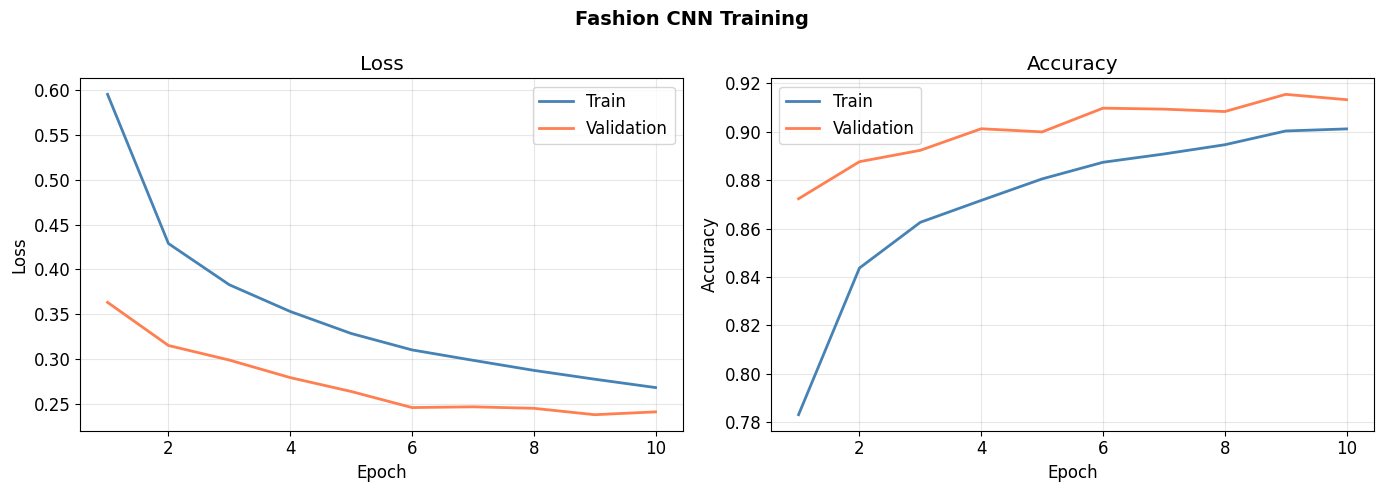

In [23]:
def plot_history(history, title='Training History'):
    """Plot loss and accuracy curves side by side."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    epochs = range(1, len(history['train_loss']) + 1)

    ax1.plot(epochs, history['train_loss'], 'steelblue', label='Train', linewidth=2)
    ax1.plot(epochs, history['val_loss'], 'coral', label='Validation', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, history['train_acc'], 'steelblue', label='Train', linewidth=2)
    ax2.plot(epochs, history['val_acc'], 'coral', label='Validation', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_history(history, 'Fashion CNN Training')

---
# Section 4: Evaluating and Inspecting the Model

Training is done. Now: how well does it actually work? And what has it learned?

### Test Set Evaluation

Important: always evaluate on the test set **once**, after all tuning is done. Don't use the test set to make training decisions — that's what validation is for.

In [24]:
# Evaluate on the held-out test set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(y_batch.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = (all_preds == all_labels).mean()
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9095


In [25]:
# Classification report: per-class precision, recall, F1
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.87      0.84      0.86      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.88      0.83      0.86      1000
       Dress       0.88      0.92      0.90      1000
        Coat       0.82      0.88      0.85      1000
      Sandal       0.99      0.98      0.98      1000
       Shirt       0.75      0.75      0.75      1000
     Sneaker       0.94      0.98      0.96      1000
         Bag       0.99      0.97      0.98      1000
  Ankle boot       0.98      0.95      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



### Confusion Matrix

The confusion matrix shows which classes the model confuses. For Fashion-MNIST, Shirt vs T-shirt/top and Shirt vs Pullover are common mix-ups.

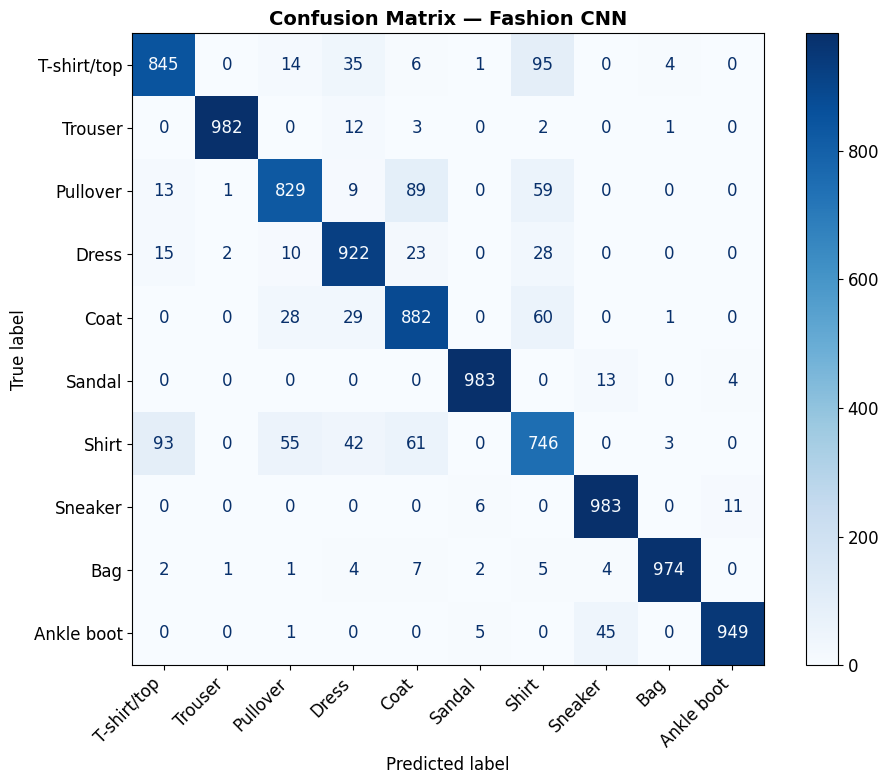

In [26]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix — Fashion CNN', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Visualizing Predictions

Looking at actual predictions — especially wrong ones — is more informative than aggregate metrics.

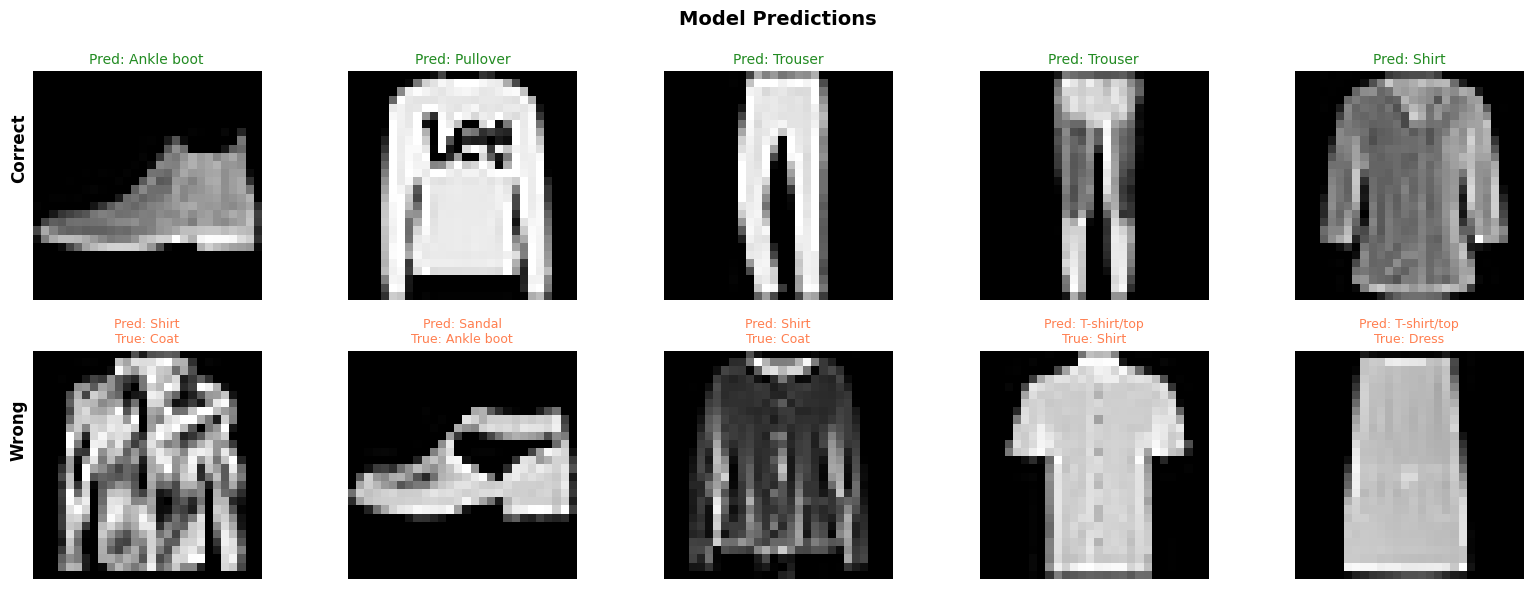

In [27]:
# Show some predictions (correct and incorrect)
wrong_idx = np.where(all_preds != all_labels)[0]
right_idx = np.where(all_preds == all_labels)[0]

fig, axes = plt.subplots(2, 5, figsize=(16, 6))

# Top row: correct predictions
fig.text(0.02, 0.75, 'Correct', fontsize=12, fontweight='bold', rotation=90, va='center')
for i, ax in enumerate(axes[0]):
    idx = right_idx[i]
    ax.imshow(X_test_np[idx], cmap='gray')
    ax.set_title(f'Pred: {class_names[all_preds[idx]]}', color='forestgreen', fontsize=10)
    ax.axis('off')

# Bottom row: incorrect predictions
fig.text(0.02, 0.28, 'Wrong', fontsize=12, fontweight='bold', rotation=90, va='center')
for i, ax in enumerate(axes[1]):
    idx = wrong_idx[i]
    ax.imshow(X_test_np[idx], cmap='gray')
    ax.set_title(f'Pred: {class_names[all_preds[idx]]}\nTrue: {class_names[all_labels[idx]]}',
                 color='coral', fontsize=9)
    ax.axis('off')

plt.suptitle('Model Predictions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Visualizing Learned Filters

The first convolutional layer's filters show what low-level features the network learned to detect. Compare these to the hand-designed edge detectors from Session 15.

Conv1 filters shape: (32, 1, 3, 3)  (out_channels, in_channels, H, W)


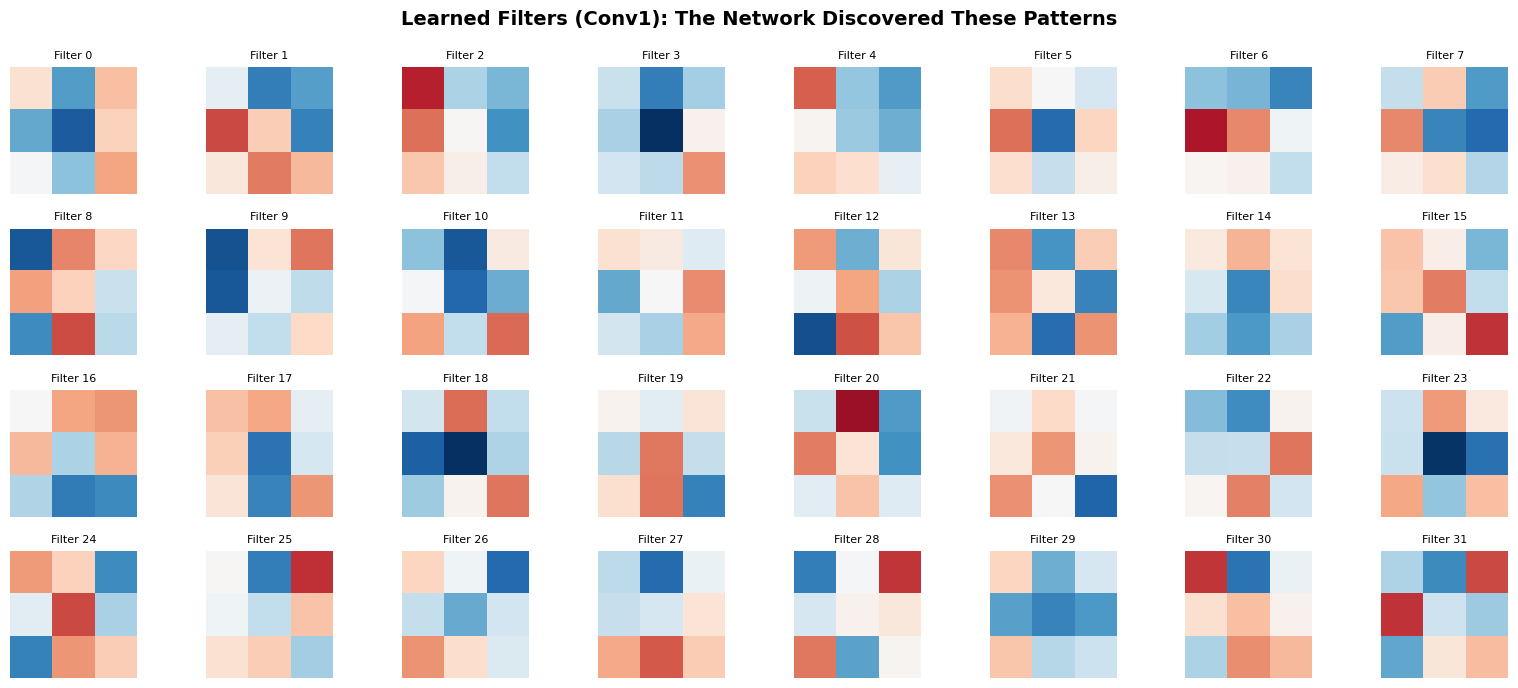

In [28]:
# Visualize first conv layer filters
filters = model.conv1.weight.data.cpu().numpy()
print(f"Conv1 filters shape: {filters.shape}  (out_channels, in_channels, H, W)")

fig, axes = plt.subplots(4, 8, figsize=(16, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(filters[i, 0], cmap='RdBu_r', vmin=-0.5, vmax=0.5)
    ax.set_title(f'Filter {i}', fontsize=8)
    ax.axis('off')
plt.suptitle('Learned Filters (Conv1): The Network Discovered These Patterns',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Saving and Loading Models

For Project 4, you may want to save a trained model and reload it later — especially if training takes a while on Colab.

In [ ]:
# Save the model weights
torch.save(model.state_dict(), 'fashion_cnn.pth')
print("Model saved to fashion_cnn.pth")

# Load into a new model instance
loaded_model = FashionCNN().to(device)
loaded_model.load_state_dict(torch.load('fashion_cnn.pth', map_location=device))
loaded_model.eval()
print("Model loaded successfully!")

# Verify it produces the same predictions
with torch.no_grad():
    sample = X_test_pt[:5].to(device)
    original_preds = model(sample).argmax(1)
    loaded_preds = loaded_model(sample).argmax(1)
    print(f"Original predictions: {original_preds.tolist()}")
    print(f"Loaded predictions:   {loaded_preds.tolist()}")
    print(f"Match: {(original_preds == loaded_preds).all().item()}")

---
## Exercise 1: PyTorch CNN from Scratch

Build and train your own CNN. The architecture is described below — you write the code.

### Task 1: Define the Model

Create a CNN class called `MyCNN` with this architecture:
- Conv block 1: Conv2d(1→16, kernel_size=5, padding=2) → ReLU → MaxPool(2)
- Conv block 2: Conv2d(16→32, kernel_size=3, padding=1) → ReLU → MaxPool(2)
- Flatten → Linear(32*7*7 → 64) → ReLU → Dropout(0.5) → Linear(64 → 10)

Hint: `padding=2` with `kernel_size=5` is "same" padding (keeps spatial size).

In [ ]:
# Define MyCNN following the architecture above

# Your code here

In [ ]:
#@title Click to reveal solution

class MyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(32 * 7 * 7, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # (B,1,28,28) → (B,16,14,14)
        x = self.pool(F.relu(self.conv2(x)))  # (B,16,14,14) → (B,32,7,7)
        x = x.view(x.size(0), -1)             # (B, 1568)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

my_model = MyCNN().to(device)
print(my_model)
total = sum(p.numel() for p in my_model.parameters())
print(f"\nTotal parameters: {total:,}")

### Task 2: Train and Plot

Use the `train_model` function from above. Train for 10 epochs, then plot the history.

In [ ]:
# Train MyCNN for 10 epochs using train_model()
# Then call plot_history() on the result

# Your code here

In [ ]:
#@title Click to reveal solution

my_model = MyCNN().to(device)
my_history = train_model(my_model, train_loader, val_loader, epochs=10, lr=0.001)
plot_history(my_history, 'MyCNN Training')

### Task 3: Evaluate on Test Set

Switch to eval mode, run predictions on the test loader, and print the classification report.

In [ ]:
# Evaluate my_model on the test set
# Remember: model.eval() and torch.no_grad()
# Print test accuracy and classification_report

# Your code here

In [ ]:
#@title Click to reveal solution

my_model.eval()
my_preds = []
my_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = my_model(X_batch).argmax(1).cpu()
        my_preds.extend(preds.numpy())
        my_labels.extend(y_batch.numpy())

my_acc = np.mean(np.array(my_preds) == np.array(my_labels))
print(f"Test Accuracy: {my_acc:.4f}")
print("\nClassification Report:")
print(classification_report(my_labels, my_preds, target_names=class_names))

---
# Section 5: The Same CNN in Keras

Keras takes a different approach: instead of writing a class and a training loop, you stack layers in a `Sequential` model, then call `.compile()` and `.fit()`. The math underneath is identical — the difference is how much the framework handles for you.

We didn't get to this in Session 15, so let's walk through it carefully.

### Preparing Data for Keras

Keras expects channels-last format: `(batch, height, width, channels)`. We also split off a validation set.

In [29]:
# Keras format: (N, H, W, C) — channels LAST
X_train_keras = X_train_np[..., np.newaxis]  # (60000, 28, 28, 1)
X_test_keras = X_test_np[..., np.newaxis]

# Split: same 50k/10k as PyTorch
X_train_k = X_train_keras[:50000]
y_train_k = y_train_raw[:50000]
X_val_k = X_train_keras[50000:]
y_val_k = y_train_raw[50000:]

print(f"Keras train shape: {X_train_k.shape}  ← (N, H, W, C)")
print(f"Keras val shape:   {X_val_k.shape}")
print(f"Keras test shape:  {X_test_keras.shape}")

Keras train shape: (50000, 28, 28, 1)  ← (N, H, W, C)
Keras val shape:   (10000, 28, 28, 1)
Keras test shape:  (10000, 28, 28, 1)


### Defining the Model

In Keras, you list layers in order inside `Sequential()`. No class, no `forward()` method — just stack from top to bottom.

In [31]:
# Same architecture as FashionCNN, in Keras
keras_model = keras.Sequential([
    # Conv Block 1
    klayers.Conv2D(32, (3, 3), padding='same', input_shape=(28, 28, 1)),
    klayers.BatchNormalization(),
    klayers.Activation('relu'),
    klayers.MaxPooling2D((2, 2)),
    klayers.Dropout(0.25),

    # Conv Block 2
    klayers.Conv2D(64, (3, 3), padding='same'),
    klayers.BatchNormalization(),
    klayers.Activation('relu'),
    klayers.MaxPooling2D((2, 2)),
    klayers.Dropout(0.25),

    # Classifier head
    klayers.Flatten(),
    klayers.Dense(128, activation='relu'),
    klayers.Dropout(0.5),
    klayers.Dense(10, activation='softmax')  # Keras: softmax here, not in loss
])

keras_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,026 (1.61 MB)

 Trainable params: 421,834 (1.61 MB)

 Non-trainable params: 192 (768.00 B)

### Key Differences to Notice

**`padding='same'`** — Keras uses string names instead of padding integers. `'same'` = keep spatial dimensions; `'valid'` = no padding.

**`activation='softmax'` on the last layer** — Unlike PyTorch (where `CrossEntropyLoss` handles softmax internally), Keras separates the softmax activation and the loss. The loss function is `sparse_categorical_crossentropy` (no built-in softmax).

**`model.summary()`** — Keras has this built in. In PyTorch, you'd use `torchsummary` or the shape-tracing technique we did above.

**No `model.train()`/`model.eval()`** — Keras handles this automatically. When you call `.fit()`, dropout is on; when you call `.evaluate()` or `.predict()`, dropout is off.

### Compile and Train

`.compile()` sets up the optimizer, loss function, and metrics. `.fit()` runs the entire training loop — batching, shuffling, forward/backward/update, validation — all in one call.

In [32]:
# Compile: set optimizer, loss, and metrics
keras_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # integer labels, not one-hot
    metrics=['accuracy']
)

# Train with early stopping
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

keras_history = keras_model.fit(
    X_train_k, y_train_k,
    epochs=15,               # max epochs; early stopping may cut it short
    batch_size=64,
    validation_data=(X_val_k, y_val_k),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.7378 - loss: 0.7111 - val_accuracy: 0.8491 - val_loss: 0.4066
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8117 - loss: 0.5030 - val_accuracy: 0.8732 - val_loss: 0.3495
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8388 - loss: 0.4385 - val_accuracy: 0.8814 - val_loss: 0.3184
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8503 - loss: 0.4072 - val_accuracy: 0.8955 - val_loss: 0.2874
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8632 - loss: 0.3739 - val_accuracy: 0.8992 - val_loss: 0.2719
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8702 - loss: 0.3539 - val_accuracy: 0.9039 - val_loss: 0.2608
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8767 - loss: 0.3378 - val_accuracy: 0.9026 - val_loss: 0.2543
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8831 - loss: 0.3270 - val_accuracy: 

### Plot Keras Training History

Keras returns a `History` object with the same kind of loss/accuracy data. We just need to extract it into the same format as our PyTorch history.

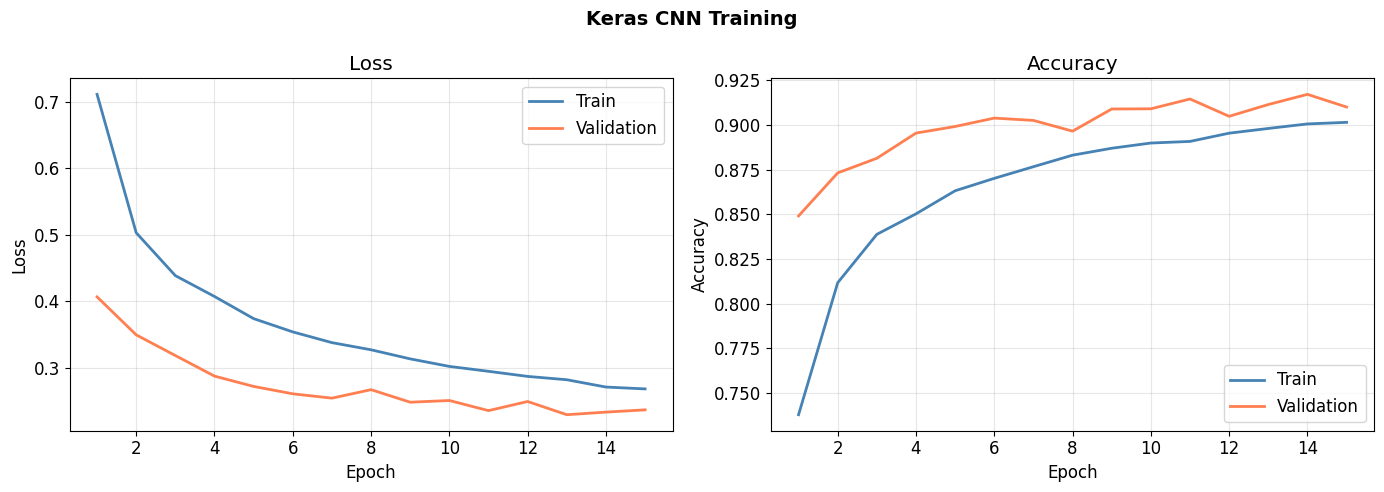

Training stopped at epoch 15 (early stopping patience=3)


In [33]:
# Convert Keras history to our plot format
keras_hist_dict = {
    'train_loss': keras_history.history['loss'],
    'val_loss': keras_history.history['val_loss'],
    'train_acc': keras_history.history['accuracy'],
    'val_acc': keras_history.history['val_accuracy']
}
plot_history(keras_hist_dict, 'Keras CNN Training')

actual_epochs = len(keras_history.history['loss'])
print(f"Training stopped at epoch {actual_epochs} (early stopping patience=3)")

### Evaluate the Keras Model

In [34]:
# Keras evaluation is one line
test_loss, test_acc = keras_model.evaluate(X_test_keras, y_test_raw, verbose=0)
print(f"Keras Test Accuracy: {test_acc:.4f}")

# Get predictions for classification report
keras_preds = keras_model.predict(X_test_keras, verbose=0).argmax(axis=1)
print("\nClassification Report:")
print(classification_report(y_test_raw, keras_preds, target_names=class_names))

Keras Test Accuracy: 0.9085

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.85      0.87      0.86      1000
     Trouser       0.99      0.98      0.98      1000
    Pullover       0.88      0.82      0.85      1000
       Dress       0.91      0.91      0.91      1000
        Coat       0.83      0.88      0.85      1000
      Sandal       0.99      0.98      0.98      1000
       Shirt       0.74      0.73      0.74      1000
     Sneaker       0.93      0.98      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.98      0.95      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



---
## Exercise 2: Build a CNN in Keras

Build a different architecture in Keras, train it, and compare.

### Task 1: Define and Compile

Build a Keras Sequential model with:
- Conv2D(16, (5,5), padding='same') → ReLU → MaxPooling2D(2,2)
- Conv2D(32, (3,3), padding='same') → ReLU → MaxPooling2D(2,2)
- Flatten → Dense(64, relu) → Dropout(0.5) → Dense(10, softmax)

Compile with adam, sparse_categorical_crossentropy, and accuracy.

In [ ]:
# Build and compile the Keras model described above

# Your code here

In [ ]:
#@title Click to reveal solution

my_keras_model = keras.Sequential([
    klayers.Conv2D(16, (5, 5), padding='same', activation='relu', input_shape=(28, 28, 1)),
    klayers.MaxPooling2D((2, 2)),
    klayers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    klayers.MaxPooling2D((2, 2)),
    klayers.Flatten(),
    klayers.Dense(64, activation='relu'),
    klayers.Dropout(0.5),
    klayers.Dense(10, activation='softmax')
])

my_keras_model.compile(optimizer='adam',
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

my_keras_model.summary()

### Task 2: Train with Early Stopping

Train for up to 15 epochs with early stopping (patience=3). Use the validation data `(X_val_k, y_val_k)`.

In [ ]:
# Train with early stopping, then plot the learning curves

# Your code here

In [ ]:
#@title Click to reveal solution

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

my_keras_hist = my_keras_model.fit(
    X_train_k, y_train_k,
    epochs=15, batch_size=64,
    validation_data=(X_val_k, y_val_k),
    callbacks=[early_stop],
    verbose=1
)

# Plot
hist_dict = {
    'train_loss': my_keras_hist.history['loss'],
    'val_loss': my_keras_hist.history['val_loss'],
    'train_acc': my_keras_hist.history['accuracy'],
    'val_acc': my_keras_hist.history['val_accuracy']
}
plot_history(hist_dict, 'My Keras CNN Training')

### Task 3: Evaluate and Compare

Print the test accuracy and compare to the PyTorch model from Exercise 1.

In [ ]:
# Evaluate on test set and print classification report

# Your code here

In [ ]:
#@title Click to reveal solution

test_loss, test_acc = my_keras_model.evaluate(X_test_keras, y_test_raw, verbose=0)
print(f"My Keras Model — Test Accuracy: {test_acc:.4f}")

my_keras_preds = my_keras_model.predict(X_test_keras, verbose=0).argmax(axis=1)
print("\nClassification Report:")
print(classification_report(y_test_raw, my_keras_preds, target_names=class_names))

---
# Section 6: PyTorch vs Keras — Side-by-Side Reference

Now that you've used both, here's a quick reference for the key differences. This is the "cheat sheet" for Project 4.

In [35]:
# Print a side-by-side comparison table
comparison = """
┌──────────────────────┬─────────────────────────────┬──────────────────────────────┐
│ Concept              │ PyTorch                     │ Keras                        │
├──────────────────────┼─────────────────────────────┼──────────────────────────────┤
│ Tensor shape (CNN)   │ (N, C, H, W) channels first │ (N, H, W, C) channels last  │
│ Model definition     │ class + __init__ + forward  │ Sequential([layers])         │
│ Conv layer           │ nn.Conv2d(in, out, k)       │ Conv2D(out, (k,k))           │
│ Padding              │ padding=1 (integer)         │ padding='same' (string)      │
│ Flatten              │ x.view(x.size(0), -1)       │ Flatten() layer              │
│ Output activation    │ raw logits (loss has softmax)│ softmax on last Dense        │
│ Loss function        │ nn.CrossEntropyLoss()       │ 'sparse_categorical_...'     │
│ Training             │ manual loop (5 lines)       │ model.fit()                  │
│ Dropout toggle       │ model.train() / model.eval()│ automatic                   │
│ Validation           │ manual with torch.no_grad() │ validation_data= in .fit()   │
│ Early stopping       │ manual (track best loss)    │ EarlyStopping callback       │
│ Save/Load            │ torch.save/load_state_dict  │ model.save / load_model      │
│ GPU                  │ .to(device) on model+data   │ automatic if GPU available   │
│ Evaluation           │ manual loop with .eval()    │ model.evaluate()             │
│ Predictions          │ model(x).argmax(1)          │ model.predict(x).argmax(1)   │
└──────────────────────┴─────────────────────────────┴──────────────────────────────┘
"""
print(comparison)


┌──────────────────────┬─────────────────────────────┬──────────────────────────────┐
│ Concept              │ PyTorch                     │ Keras                        │
├──────────────────────┼─────────────────────────────┼──────────────────────────────┤
│ Tensor shape (CNN)   │ (N, C, H, W) channels first │ (N, H, W, C) channels last  │
│ Model definition     │ class + __init__ + forward  │ Sequential([layers])         │
│ Conv layer           │ nn.Conv2d(in, out, k)       │ Conv2D(out, (k,k))           │
│ Padding              │ padding=1 (integer)         │ padding='same' (string)      │
│ Flatten              │ x.view(x.size(0), -1)       │ Flatten() layer              │
│ Output activation    │ raw logits (loss has softmax)│ softmax on last Dense        │
│ Loss function        │ nn.CrossEntropyLoss()       │ 'sparse_categorical_...'     │
│ Training             │ manual loop (5 lines)       │ model.fit()                  │
│ Dropout toggle       │ model.train() / model.eval()

### Which Should You Use for Project 4?

**Either one works.** Pick based on your comfort level:

- **Keras** if you want to spend less time on boilerplate and more time on architecture experiments. The `.fit()` loop with early stopping is hard to beat for convenience.
- **PyTorch** if you want full control over every step and a deeper understanding of what's happening. The explicit loop is more work but more transparent.

You can even prototype in Keras (fast iteration) and then port to PyTorch (more control) — the architecture translates directly.

---
## Exercise 3: Project 4 Warm-Up — End-to-End Pipeline

This exercise mirrors the workflow you'll use for Project 4. Choose either PyTorch or Keras and build a complete pipeline from data loading to evaluation.

### Task 1: Design Your Architecture

On paper (or in a comment), design a CNN architecture for Fashion-MNIST. Decide:
- How many conv blocks?
- How many filters per block?
- What regularization (dropout rates, batch norm)?
- What dense layer sizes?

Write your design as comments, then implement it.

In [ ]:
# Architecture design:
# Conv Block 1: ___
# Conv Block 2: ___
# (Optional) Conv Block 3: ___
# Classifier: ___
# Regularization: ___
#
# Expected parameter count (estimate): ___

# Implement your model below (PyTorch or Keras — your choice)

# Your code here

In [ ]:
#@title Click to reveal solution

# Example solution in PyTorch — a 3-block CNN
class ProjectWarmupCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Block 1: 1 → 32
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        # Block 2: 32 → 64
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        # Block 3: 64 → 128
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2)
        self.dropout_conv = nn.Dropout2d(0.25)
        self.dropout_fc = nn.Dropout(0.5)

        # After 3 pools: 28 → 14 → 7 → 3 (floor of 7/2)
        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.dropout_conv(x)
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.dropout_conv(x)
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.dropout_conv(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout_fc(x)
        x = self.fc2(x)
        return x

warmup_model = ProjectWarmupCNN().to(device)
total = sum(p.numel() for p in warmup_model.parameters())
print(warmup_model)
print(f"\nTotal parameters: {total:,}")

### Task 2: Train and Monitor

Train your model. Watch the loss curves — is it overfitting? Does it converge?

In [ ]:
# Train your model and plot the learning curves

# Your code here

In [ ]:
#@title Click to reveal solution

warmup_model = ProjectWarmupCNN().to(device)
warmup_history = train_model(warmup_model, train_loader, val_loader, epochs=15, lr=0.001)
plot_history(warmup_history, 'Project Warmup CNN')

### Task 3: Evaluate and Analyze

Evaluate on the test set. Which classes does your model struggle with? How does it compare to the demo models?

In [ ]:
# Evaluate on test set: accuracy, classification report, confusion matrix

# Your code here

In [ ]:
#@title Click to reveal solution

warmup_model.eval()
wp_preds = []
wp_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = warmup_model(X_batch).argmax(1).cpu()
        wp_preds.extend(preds.numpy())
        wp_labels.extend(y_batch.numpy())

print(f"Test Accuracy: {np.mean(np.array(wp_preds) == np.array(wp_labels)):.4f}")
print("\nClassification Report:")
print(classification_report(wp_labels, wp_preds, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(wp_labels, wp_preds)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix — Warmup CNN', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
# Summary

**PyTorch data pipeline:** Dataset → DataLoader → iterate batches. Set `shuffle=True` for training, `False` for validation/test.

**CNN in PyTorch:** Subclass `nn.Module`, define layers in `__init__`, wire them in `forward()`. The architecture is explicit — you see every operation.

**The training loop:** `model.train()` → iterate batches → zero_grad → forward → loss → backward → step. Then `model.eval()` + `torch.no_grad()` for validation.

**`model.train()` vs `model.eval()`:** Controls dropout and batch norm behavior. Forgetting to switch is a common bug.

**CNN in Keras:** `Sequential()` + `.compile()` + `.fit()`. Less code, same math. Dropout and eval mode are handled automatically.

**Debugging:** Check tensor shapes with a dummy batch. Visualize learned filters. Look at wrong predictions, not just accuracy.

**For Project 4:** Pick PyTorch or Keras, build a CNN, train with validation monitoring, evaluate with classification report and confusion matrix. The patterns in this notebook are exactly what you'll use.